In [1]:
import libs.append_path
from add_python_libraries import *
#import pd_filter_fcns
import pandas as pd
import numpy as np
import scipy as sp
#import numpy_rms
#import pathlib

from capacitorZ_multibank import Zcapbanks, Zcapbanks_df
from capacitor_selection_tables import Cap_selector #create_mlcc_selection_table, create_sp_selection_table, create_allcaps_selected_df

from cyntec import Inductor_pdis

from current_buck_waveforms import Current_buck_waveforms
from current_carova_MR_waveforms import Current_carova_MR_waveforms

from current_buck_fft import Current_buck_FFT

from current_capbanks_fft import Current_capbanks_FFT
from current_capbanks_waveforms import Current_capbanks_waveforms

from voltage_capbanks_waveform import Vripple_capbanks_waveforms

In [2]:
input_params = {'vin' : 36,
                'vout': 11.1,
                'pin' : 180, 
                'eff' : 0.97, 
                'fs'  :300e3,
                'ton_mult':1,
                #'ddiv':4,
                'tambient':25,
                'lout':{'family'   :'cmle104t',#'hbed053t',
                        'value(uH)':1.5,
                        'config'   :'single'},
                'lvl_config':'3 level carova',
               }
input_params['iout'] = input_params['pin']*input_params['eff']/input_params['vout']
vbias = input_params['vin']
lobj = Inductor_pdis(input_params)
iobj = {True:Current_carova_MR_waveforms,
        False:Current_buck_waveforms}[lobj.ckt['state count']==6](lobj)

In [3]:
cap_selector_obj = Cap_selector(vbias)

## Select MLCC cap quantity (last column)

In [4]:
datagrid1 = cap_selector_obj.create_mlcc_selection_table()
datagrid1

DataGrid(auto_fit_columns=True, auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_render…

In [5]:
cap_selector_obj.save_to_file(datagrid1,'180w_mlcc.csv')

In [6]:
#cap_selector_obj.save_to_file(datagrid2,'tmp2.csv')

In [7]:
cap_selector_obj.load_from_file(datagrid1,'tmp.csv')

## Select SP cap quantity (last column)

In [6]:
datagrid2 = cap_selector_obj.create_sp_selection_table()
datagrid2

DataGrid(auto_fit_columns=True, auto_fit_params={'area': 'all', 'padding': 30, 'numCols': None}, corner_render…

In [9]:
cap_selector_obj.load_from_file(datagrid2,'tmp2.csv')

In [7]:
df_allcaps_selected = cap_selector_obj.create_allcaps_selected_df(datagrid1,datagrid2)
df_allcaps_selected

TypeError: Cap_selector.create_allcaps_selected_df() missing 1 required positional argument: 'a_or_b'

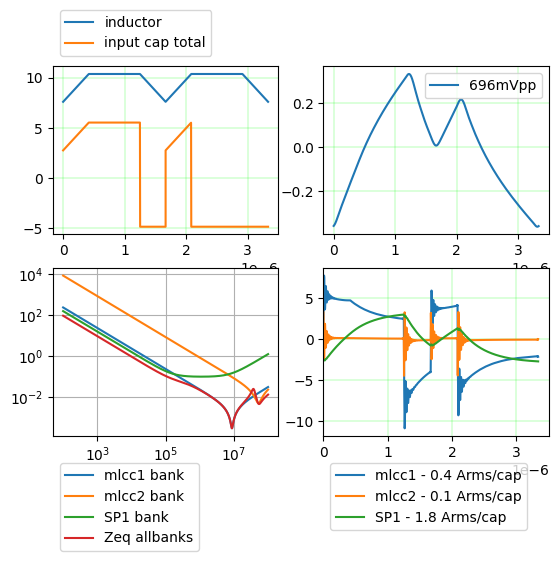

In [18]:
currents_buckfftobj = Current_buck_FFT(iobj)
zcapbanks_obj = Zcapbanks_df(df_allcaps_selected)
zcapbanks_obj2 = Zcapbanks(zcapbanks_obj.listofbanks)
currents_capsfftobj = Current_capbanks_FFT(currents_buckfftobj,zcapbanks_obj2)
i_zbank_ac_obj = Current_capbanks_waveforms(currents_capsfftobj)
vcap_obj = Vripple_capbanks_waveforms(i_zbank_ac_obj,bw=10e6)
fig, ax = plt.subplots(2,2)
iobj.plot_waveforms(ax[0,0])
i_zbank_ac_obj.plot_ibanks(ax[1,1])
vcap_obj.plot_vripple(ax[0,1])
zcapbanks_obj.plot_Zbanks(ax[1,0])

In [19]:
zcapbanks_obj.listofbanks


[{'label': 'mlcc1',
  'type': 'mlcc',
  'C': 6.62e-07,
  'ESR': 0.003,
  'ESL': 5e-10,
  'n': 10,
  'series': 0,
  'fftdata': array([ 3.70895359e-14+1.38403379e-19j,  6.95156893e+02-1.44551166e+03j,
          2.04666415e+02-1.31517838e+03j, ...,
         -1.86976202e+02-7.15690299e+02j,  2.04666415e+02+1.31517838e+03j,
          6.95156893e+02+1.44551166e+03j], shape=(1024,))},
 {'label': 'mlcc2',
  'type': 'mlcc',
  'C': 4.5999999999999995e-08,
  'ESR': 0.02,
  'ESL': 2.0000000000000003e-10,
  'n': 4,
  'series': 0,
  'fftdata': array([ 1.03088740e-15+3.85376604e-21j,  1.93802969e+01-4.00929556e+01j,
          5.80998472e+00-3.63658553e+01j, ...,
         -5.26456984e+00-1.96574143e+01j,  5.80998472e+00+3.63658553e+01j,
          1.93802969e+01+4.00929556e+01j], shape=(1024,))},
 {'label': 'SP1',
  'type': 'SP',
  'C': 9.999999999999999e-06,
  'ESR': 0.1,
  'ESL': 2e-09,
  'n': 1,
  'series': 0,
  'fftdata': array([ 5.60264892e-14-1.42257145e-19j, -7.07183986e+02-9.11159543e+02j,
    

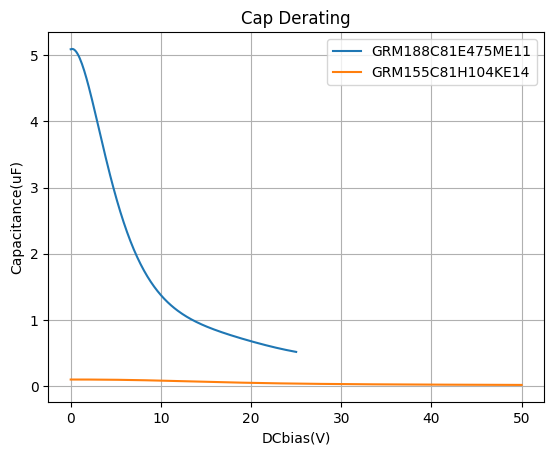

In [16]:
cap_obj_list = cap_selector_obj.cap_obj_list
x = 'DCbias(V)'; y='Capacitance(uF)'; title='Cap Derating'
ax=cap_obj_list[0].df_cap_vs_bias.plot(x=x,y=y,title=title, label=cap_obj_list[0].df_param.partnum[0])
for idx,cap_obj in enumerate(cap_obj_list):
    if idx !=0:
        cap_obj.df_cap_vs_bias.plot(ax=ax,x=x,y=y,title=title, label=cap_obj.df_param.partnum[0])
        
ax.set_ylabel('Capacitance(uF)')
ax.grid(True)

In [17]:
cap_obj_list